# H-006 · Kalman β vs static OLS hedge (trad-z)

Requires frozen `BREAK_STAR` plus H-005 window STARs (`OLS_WINDOW_STAR`, `ADF_WINDOW_STAR`, `ENTRY_Z_STAR`, `Z_WINDOW_STAR`). Bake-off under that stack.

Freeze on fold-val Sharpe (max DD / corr to S1 as secondary). ADF / HL / lag-1 autocorr are **not** freeze inputs. Type `HEDGE_STAR` (`"ols"` or `"kalman"`); if Kalman, also type `KALMAN_DELTA_STAR`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)


stack keys: ['ADF_WINDOW_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'ENTRY_Z_STAR', 'HEDGE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR', 'UNIVERSE_STAR', 'Z_WINDOW_STAR']
UNIVERSE D PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
for key in ("BREAK_STAR", "OLS_WINDOW_STAR", "ADF_WINDOW_STAR", "ENTRY_Z_STAR", "Z_WINDOW_STAR"):
    require_star(key, stack.get(key))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
# Start from OLS panel with frozen windows; Kalman arm overlays in the bake-off.
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
print("windows", {k: lb[k] for k in ("ols_window", "z_window", "adf_window")})
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 16177 OOS rows 3492
windows {'ols_window': 252, 'z_window': 90, 'adf_window': 252}


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1990-01-02,WSO|WSO.B,WSO,WSO.B,1.112374,1.112374,1.112374,1.112374,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach Kalman hedge columns (OLS panel already loaded)


In [3]:
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
KALMAN_DELTA_GRID = (1e-4, 1e-5, 1e-6, 1e-7)
CHAN_SANITY_DELTA = 1e-3


def _hedge_diag(panel, label):
    g = panel.groupby("pair_id")
    return pd.DataFrame(
        {
            "median_adf": g["adf_pvalue"].median(),
            "median_hl": g["half_life"].median(),
            "lag1_ac": g["spread"].apply(lambda s: float(s.astype(float).autocorr(lag=1))),
        }
    ).assign(arm=label)


kf_panels = {}
rows = [_hedge_diag(is_panel, "ols")]
for d in (CHAN_SANITY_DELTA,) + KALMAN_DELTA_GRID:
    p = overlay_kalman_hedge(
        is_panel.copy(),
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=d,
    )
    if d in KALMAN_DELTA_GRID:
        kf_panels[d] = p
    rows.append(_hedge_diag(p, f"kalman_{d:g}"))

diag = pd.concat(rows)
print("ADF/HL/autocorr diagnostic (not a freeze input). Expect lag1_ac and HL to rise toward OLS as δ shrinks.")
print("Chan δ=1e-4 is sanity contrast only — not a freeze candidate.")
diag


ADF/HL/autocorr diagnostic (not a freeze input). Expect lag1_ac and HL to rise toward OLS as δ shrinks.
Chan δ=1e-4 is sanity contrast only — not a freeze candidate.


,median_adf,median_hl,lag1_ac,arm
pair_id,,,,
HEI|HEI.A,2.119185e-01,11.147576,0.956978,ols
NWS|NWSA,9.642348e-02,5.979501,0.945077,ols
WSO|WSO.B,6.749013e-09,1.580584,0.900854,ols
HEI|HEI.A,2.325014e-24,0.340605,0.085434,kalman_0.001
NWS|NWSA,5.937410e-24,0.203080,-0.098920,kalman_0.001
WSO|WSO.B,4.018831e-18,0.296161,-0.027980,kalman_0.001
HEI|HEI.A,2.554740e-15,0.574415,0.433312,kalman_0.0001
NWS|NWSA,1.206761e-19,0.506670,0.216471,kalman_0.0001
WSO|WSO.B,9.535770e-16,0.584549,0.265730,kalman_0.0001


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(is_panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1990-01-02,1997-12-11,2011,1997-12-12,1997-12-18,1997-12-19,2005-12-23,2016
1,2,1990-01-02,2005-12-16,4027,2005-12-19,2005-12-23,2005-12-27,2013-12-30,2016
2,3,1990-01-02,2013-12-20,6043,2013-12-23,2013-12-30,2013-12-31,2021-12-31,2016


## 4. Fold-val metrics (validation only)


In [5]:
cfg_ols = config_from_stack(stack, hedge="ols")
parts = [fold_val_metrics(is_panel, folds, {"ols": cfg_ols}, s1_weekly=s1_weekly)]
cfg_kf = config_from_stack(stack, hedge="kalman")
for d, panel in kf_panels.items():
    arm = f"kalman_{d:g}"
    parts.append(fold_val_metrics(panel, folds, {arm: cfg_kf}, s1_weekly=s1_weekly))
fold_df = pd.concat(parts, ignore_index=True)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,ols,1,1.650232,-0.045356,NaN,2014,124,0.913837,2.834209,2.834209
1,ols,2,0.713229,-0.026771,NaN,2014,186,0.967603,1.262083,1.262083
2,ols,3,1.617463,-0.026987,-0.111699,2014,176,0.966104,5.237958,5.237958
3,kalman_0.0001,1,1.336913,-0.079586,NaN,2014,310,0.969843,0.693010,0.693010
4,kalman_0.0001,2,0.467990,-0.052206,NaN,2014,384,0.971442,0.624324,0.624324
5,kalman_0.0001,3,-0.010135,-0.093648,-0.099279,2014,609,1.000000,0.373349,0.373349
6,kalman_1e-05,1,1.797164,-0.062533,NaN,2014,224,0.969843,1.270531,1.270531
7,kalman_1e-05,2,0.495962,-0.051708,NaN,2014,311,0.971442,0.887701,0.887701
8,kalman_1e-05,3,0.448032,-0.100945,-0.082363,2014,451,1.000000,1.036843,1.036843
9,kalman_1e-06,1,1.976776,-0.057847,NaN,2014,179,0.969843,2.234590,2.234590


## 5. Boxplots (do not assign STAR here)


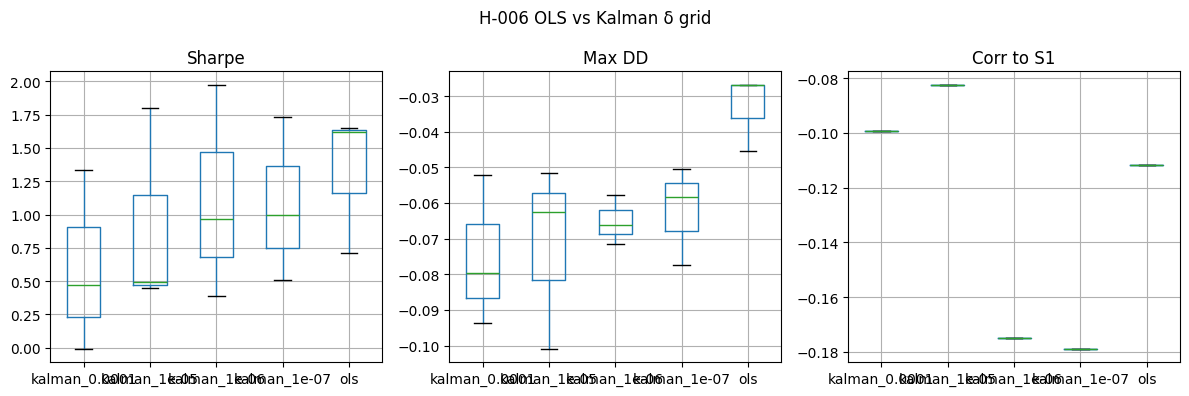

median-Sharpe hint (commentary only): ols


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
kalman_0.0001,0.467990,-0.079586,-0.099279
kalman_1e-05,0.495962,-0.062533,-0.082363
kalman_1e-06,0.965327,-0.066150,-0.174955
kalman_1e-07,0.997226,-0.058373,-0.178948
ols,1.617463,-0.026987,-0.111699


In [6]:
plot_fold_boxplots(fold_df, title="H-006 OLS vs Kalman δ grid")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
fold_df.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


## 6. Type `HEDGE_STAR` (and `KALMAN_DELTA_STAR` if Kalman) then save


In [7]:
HEDGE_STAR = "ols"  # TODO after fold-val review: "ols" or "kalman"
KALMAN_DELTA_STAR = None  # TODO if Kalman: 1e-5, 1e-6, or 1e-7 (not 1e-4)
require_star("HEDGE_STAR", HEDGE_STAR)
stack["HEDGE_STAR"] = HEDGE_STAR
if HEDGE_STAR == "kalman":
    require_star("KALMAN_DELTA_STAR", KALMAN_DELTA_STAR)
    dstar = float(KALMAN_DELTA_STAR)
    if not any(abs(dstar - d) < 1e-12 for d in KALMAN_DELTA_GRID):
        raise ValueError(f"KALMAN_DELTA_STAR must be one of {KALMAN_DELTA_GRID}, got {KALMAN_DELTA_STAR!r}")
    stack["KALMAN_DELTA_STAR"] = dstar
else:
    stack["KALMAN_DELTA_STAR"] = None
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH, "HEDGE_STAR", HEDGE_STAR, "KALMAN_DELTA_STAR", stack.get("KALMAN_DELTA_STAR"))


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json HEDGE_STAR ols KALMAN_DELTA_STAR None


## 7. Sealed OOS once


In [ ]:
require_star("HEDGE_STAR", HEDGE_STAR)
oos_use = oos_panel
if HEDGE_STAR == "kalman":
    require_star("KALMAN_DELTA_STAR", KALMAN_DELTA_STAR)
    oos_use = overlay_kalman_hedge(
        oos_panel.copy(),
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=float(KALMAN_DELTA_STAR),
    )
oos = run_s2_backtest(oos_use, config_from_stack(stack), s1_weekly=s1_weekly)
print(oos.metrics)
arm_label = HEDGE_STAR if HEDGE_STAR == "ols" else f"kalman_{float(KALMAN_DELTA_STAR):g}"
write_tearsheet_pdf(tearsheet_path("H-006", arm_label), oos.returns, title=f"H-006 {arm_label} sealed OOS")
print("tearsheet", tearsheet_path("H-006", arm_label))


## 8. Notes for next hyp


H-007 spread ADX/RSI filter is next. TA-Lib required for that notebook. Leave `HEDGE_STAR`, `KALMAN_DELTA_STAR`, `BREAK_STAR`, and window STARs frozen. If 1h is ever re-opened, Kalman Q should be ≈ Q_day/6 so calendar adaptation matches (do not session-scale δ on 1d).
